In [1]:
import numpy as np
import pandas as pd
import torch as pt
import seaborn as sns
import matplotlib.pyplot as plt
from Functional_Fusion.dataset import DataSetMDTB
import os
import Functional_Fusion.atlas_map as am
import PcmPy as pcm
from MultiTaskBattery.optimal_battery import eigenval_crit,build_combinations


In [2]:
# Define ROIs to be used for the analysis
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'

space = 'SUIT3'
atlas, _ = am.get_atlas(space)

In [3]:
# Load the data
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

#make nans zero
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0


# get the G matrix

In [4]:
n_conds = len(np.unique(info_mdtb_1['cond_name']))
n_runs = len(np.unique(info_mdtb_1['run']))
cond_names = np.unique(info_mdtb_1['cond_name'])

In [5]:
cond_vec = np.tile(np.arange(1, n_conds + 1), n_runs)
part_vec = np.repeat(np.arange(1, n_runs + 1), n_conds)

Gs_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


<Axes: >

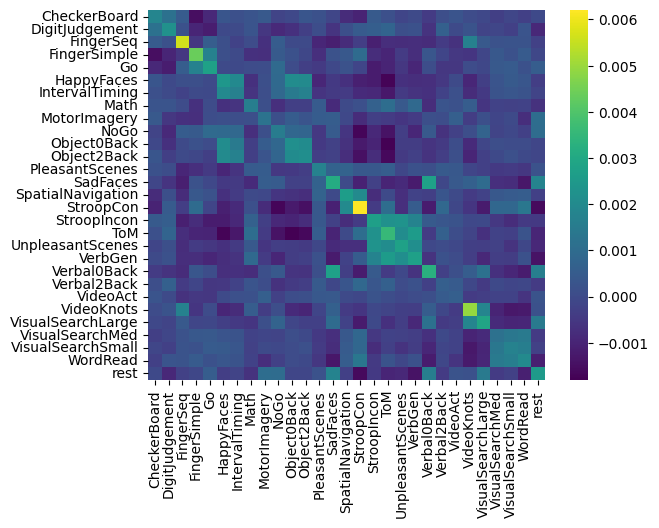

In [6]:
sns.heatmap(G_individuals_averaged, cmap='viridis',xticklabels=cond_names, yticklabels=cond_names)

# Build combinations

In [7]:
D = build_combinations(G_individuals_averaged, strategy='random',n_iter=1000,n_tasks=4)

In [10]:
A= D[D.offset==0.001]
